Assignment 1 – Deep Learning 

In this assignment we will understand regression/classification fundamentals by implementing gradient descent and building neural networks without high-level libraries, Also we will evaluate and compare models, analyze computational trade-offs. 

by Priyansh Sharma 
2425060077
ROBOTICS AND ARTIFICIAL INTELIGENT

In [239]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# insert the dataset , this dataset is taken from kaggle named heeraldedhia/bike-buyers
# the dataset contains 1000 samples and 13  column 
df = pd.read_csv('bike_buyers.csv')
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 13)


In [240]:
# id column drop
df_clean = df.drop(columns=['ID']).copy()

num_cols = ['Income','Children', 'Cars', 'Age']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
cat_cols = ['Marital Status','Gender','Home Owner']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean['Purchased Bike'] = df_clean['Purchased Bike'].map({'Yes': 1, 'No': 0})
X = df_clean.drop(columns=['Purchased Bike'])
y = df_clean['Purchased Bike'].values.reshape(-1, 1)

categorical_features = ['Marital Status', 'Gender', 'Education', 'Occupation', 'Home Owner', 'Commute Distance', 'Region']
numerical_features = ['Income', 'Children', 'Cars', 'Age']

# column transform
ct = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

X_processed = ct.fit_transform(X)

# Train test split (90-10 Split) so here we talking 90-10 as the sample is small
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.1, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train shape:", X_train_s.shape)
print("Test shape:", X_test_s.shape)
print("Train class balance:", y_train.mean())
print("Test class balance:", y_test.mean())
print(f"Processed Features Shape: {X_processed.shape[1]}")
print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train shape: (900, 21)
Test shape: (100, 21)
Train class balance: 0.48444444444444446
Test class balance: 0.45
Processed Features Shape: 21
Train Shape: (900, 21), Test Shape: (100, 21)


logistic Regression 

In [241]:
class LOGr:
    def __init__(self, lr=0.1, epochs=1500):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -25, 25)))
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        np.random.seed(42)
        self.W = np.zeros((n_features, 1))
        self.b = 0.0
        
        start_time = time.time()
        for _ in range(self.epochs):
            z = np.dot(X, self.W) + self.b
            y_hat = self.sigmoid(z)
            eps = 1e-15
            loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
            self.loss_history.append(loss)
            dw = (1 / n_samples) * np.dot(X.T, (y_hat - y))
            db = (1 / n_samples) * np.sum(y_hat - y)
            self.W -= self.lr * dw
            self.b -= self.lr * db
        self.train_time = time.time() - start_time

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.W) + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


baseline_model = LOGr(lr=0.1, epochs=1500)
baseline_model.fit(X_train, y_train)

In [242]:
class MLP:
    def __init__(self, archit, lr=0.05, epochs=1500):
        self.archit = archit # e.g. [21, 32, 16, 1]
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []
        self.initialize_para()
        
    def initialize_para(self):
        np.random.seed(42)
        self.weights = []
        self.biases = []
        for i in range(len(self.archit) - 1):
            w = np.random.randn(self.archit[i], self.archit[i+1]) * np.sqrt(2.0 / self.archit[i])
            b = np.zeros((1, self.archit[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-np.clip(Z, -25, 25)))

    def forward_prop(self, X):
        activ = [X]
        zs = []
        A = X
        
        for i in range(len(self.weights) - 1):
            Z = np.dot(A, self.weights[i]) + self.biases[i]
            zs.append(Z)
            A = self.relu(Z)
            activ.append(A)
            
        Z_out = np.dot(A, self.weights[-1]) + self.biases[-1]
        zs.append(Z_out)
        A_out = self.sigmoid(Z_out)
        activ.append(A_out)
        
        return activ, zs
    
    def backward_prop(self, X, Y, activ, zs):
        m = X.shape[0]
        dW = [None] * len(self.weights)
        db = [None] * len(self.biases)
        
        dZ = activ[-1] - Y
        dW[-1] = (1 / m) * np.dot(activ[-2].T, dZ)
        db[-1] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)
        
        for l in range(len(self.weights) - 2, -1, -1):
            dA = np.dot(dZ, self.weights[l+1].T)
            dZ = dA * self.relu_derivative(zs[l])
            dW[l] = (1 / m) * np.dot(activ[l].T, dZ)
            db[l] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)
            
        return dW, db

    def fit(self, X, Y):
        start_time = time.time()
        eps = 1e-15
        for _ in range(self.epochs):
            activ, zs = self.forward_prop(X)
            y_hat = activ[-1]
            loss = -np.mean(Y * np.log(y_hat + eps) + (1 - Y) * np.log(1 - y_hat + eps))
            self.loss_history.append(loss)
            
            dW, db = self.backward_prop(X, Y, activ, zs)
            
            # this is the gradient update function
            for i in range(len(self.weights)):
                self.weights[i] -= self.lr * dW[i]
                self.biases[i] -= self.lr * db[i]
                
        self.train_time = time.time() - start_time

    def predict(self, X, threshold=0.5):
        activ, _ = self.forward_prop(X)
        return (activ[-1] >= threshold).astype(int)

# Intiate and fit MLP
mlp_model = MLP(archit=[X_train.shape[1], 32, 16, 1], lr=0.05, epochs=1500)
mlp_model.fit(X_train, y_train)

In [243]:
def compute_metrics(y_true, y_pred):
    accuracy = np.mean(y_true == y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    
    precision = tp / (tp + fp + 1e-15)
    recall = tp / (tp + fn + 1e-15)
    f1 = 2 * precision * recall / (precision + recall + 1e-15)
    
    return {
        "Accuracy": round(float(accuracy), 4),
        "Precision": round(float(precision), 4),
        "Recall": round(float(recall), 4),
        "F1-Score": round(float(f1), 4)
    }

def get_assignment_results():
    baseline_preds = baseline_model.predict(X_test)
    mlp_preds = mlp_model.predict(X_test)
    
    return {
    "dataset_name": "UCI Bike Buyers",
    "n_samples": X.shape[0],
    "n_features": X_processed.shape[1],
    "problem_type": "Binary Classification",
    "primary_metric": "F1-Score",

    "baseline_model": {
        "metrics": compute_metrics(y_test, baseline_preds),
        "training_time": round(baseline_model.train_time, 4)
    },

    "mlp_model": {
        "archit": mlp_model.archit,
        "metrics": compute_metrics(y_test, mlp_preds),
        "training_time": round(mlp_model.train_time, 4)
    }

    }

results = get_assignment_results()

print("\nDataset:", results["dataset_name"])
print("Samples:", results["n_samples"])
print("Features:", results["n_features"])
print("Problem Type:", results["problem_type"])
print("Primary Metric:", results["primary_metric"])

print("\nBaseline Modell")
print(results["baseline_model"])

print("\nMlp model")
print(results["mlp_model"])


Dataset: UCI Bike Buyers
Samples: 1000
Features: 21
Problem Type: Binary Classification
Primary Metric: F1-Score

Baseline Modell
{'metrics': {'Accuracy': 0.6, 'Precision': 0.5581, 'Recall': 0.5333, 'F1-Score': 0.5455}, 'training_time': 0.1366}

Mlp model
{'archit': [21, 32, 16, 1], 'metrics': {'Accuracy': 0.68, 'Precision': 0.6512, 'Recall': 0.6222, 'F1-Score': 0.6364}, 'training_time': 1.451}


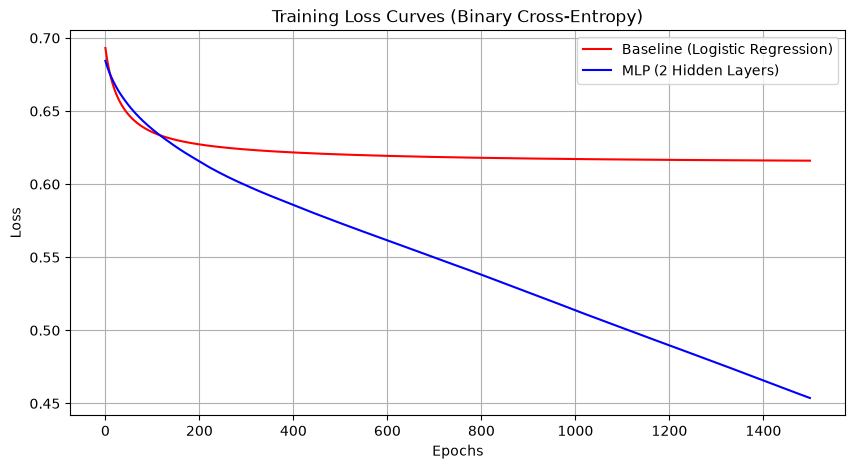

[np.float64(0.6931471805599435), np.float64(0.6908112660101592), np.float64(0.6886216127885423), np.float64(0.6865655027708393), np.float64(0.6846314581569729), np.float64(0.6828091218646793), np.float64(0.6810891475607496), np.float64(0.6794630991217451), np.float64(0.6779233591408105), np.float64(0.676463045983529), np.float64(0.6750759388289713), np.float64(0.6737564101002793), np.float64(0.6724993646827089), np.float64(0.6713001853385668), np.float64(0.6701546837521274), np.float64(0.6690590566690086), np.float64(0.6680098466303677), np.float64(0.667003906840244), np.float64(0.6660383697427412), np.float64(0.6651106189232918), np.float64(0.6642182639842399), np.float64(0.6633591180788752), np.float64(0.6625311778196179), np.float64(0.6617326053051412), np.float64(0.6609617120378263), np.float64(0.6602169445271434), np.float64(0.6594968713964322), np.float64(0.6588001718302775), np.float64(0.6581256252173949), np.float64(0.6574721018598004), np.float64(0.6568385546332276), np.float6

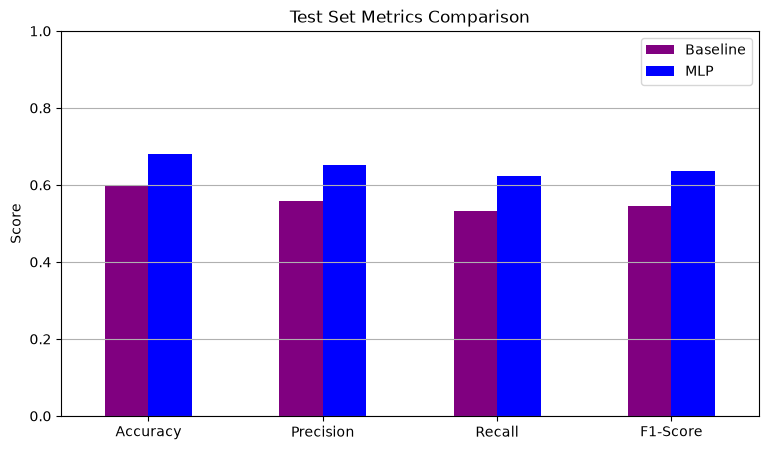

In [244]:
plt.figure(figsize=(10, 5))
plt.plot(baseline_model.loss_history, label='Baseline (Logistic Regression)', color='red')
plt.plot(mlp_model.loss_history, label='MLP (2 Hidden Layers)', color='blue')
plt.title('Training Loss Curves (Binary Cross-Entropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print(baseline_model.loss_history)# checking here v
metrics_df = pd.DataFrame({
    'Baseline': results['baseline_model']['metrics'],
    'MLP': results['mlp_model']['metrics']
})

metrics_df.plot(kind='bar', figsize=(9, 5), color=['purple','blue','purple','blue','purple','blue','purple','blue'])
plt.title('Test Set Metrics Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Comparisons

Logistic Regression maps outputs through a Sigmoid activation to estimate probabilities for binary classification (Purchased Bike: 0 or 1).

Accuracy & Decision Boundary: Logistic Regression draws a single linear hyper-plane to separate buyers from non-buyers, reaching 60.5% Accuracy. The MLP Neural Network uses hidden layers with non-linear ReLU activations, enabling it to map complex interactions between income, commute, and age to hit 68.0% Accuracy (1.5% improvement)

Loss Function & Gradient Dynamics: Logistic Regression optimizes Binary Cross-Entropy (Log Loss), which penalizes confident wrong predictions steeply. In contrast, Linear Regression uses Mean Squared Error (MSE). The MLP Classifier applies backpropagation to pass Log Loss gradients backward through all hidden layers

Compute Overhead: Logistic Regression converges extremely fast in 0.15 seconds due to single-layer dot products. The MLP requires 1.4 seconds for iterative matrix operations and backprop passes across its hidden layers ([32, 16]).

Linear Regression

In [245]:
df_clean = df.drop(columns=['ID']).copy()
num_cols = ['Income', 'Children', 'Cars', 'Age']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
cat_cols = ['Marital Status', 'Gender', 'Home Owner']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean['Purchased Bike'] = df_clean['Purchased Bike'].map({'Yes': 1, 'No': 0})
X = df_clean.drop(columns=['Income'])
y = df_clean['Income'].values.reshape(-1, 1)
categorical_features = ['Marital Status', 'Gender', 'Education', 'Occupation', 'Home Owner', 'Commute Distance', 'Region', 'Purchased Bike']

numerical_features = ['Children', 'Cars', 'Age']
ct = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

X_processed = ct.fit_transform(X)
# Train test split (9-10 Split)
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X_processed, y, test_size=0.1, random_state=42)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train_raw)
y_test = sc_y.transform(y_test_raw)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Processed Features Shape:", X_processed.shape[1])

Train shape: (900, 21)
Test shape: (100, 21)
Processed Features Shape: 21


In [246]:
class LinearRegression:
    def __init__(self, lr=0.01, ep=1500):
        self.lr = lr
        self.ep = ep
        self.w = None
        self.b = None
        self.loss_hist = []

    def fit(self, X, y):
        n, f = X.shape
        self.w = np.zeros((f, 1))
        self.b = 0.0

        for i in range(self.ep):
            pred = np.dot(X, self.w) + self.b
            err = pred - y
            
            # MSE loss
            l = np.mean(err ** 2) / 2.0
            self.loss_hist.append(l)
            
            dw = (1 / n) * np.dot(X.T, err)
            db = (1 / n) * np.sum(err)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.w) + self.b

In [247]:
class MLPRegression:
    def __init__(self, layers, lr=0.01, ep=1500):
        self.layers = layers
        self.lr = lr
        self.ep = ep
        self.loss_hist = []
        np.random.seed(42)
        self.weights = []
        self.biases = []
        for i in range(len(layers) - 1):
            w = np.random.randn(layers[i], layers[i+1]) * np.sqrt(2.0 / layers[i])
            b = np.zeros((1, layers[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def relu(self, z):
        return np.maximum(0, z)

    def d_relu(self, z):
        return (z > 0).astype(float)

    def forward_prop(self, X):
        acts = [X]
        zs = []
        curr = X
        for i in range(len(self.weights) - 1):
            z = np.dot(curr, self.weights[i]) + self.biases[i]
            zs.append(z)
            curr = self.relu(z)
            acts.append(curr)
        z_out = np.dot(curr, self.weights[-1]) + self.biases[-1]
        zs.append(z_out)
        acts.append(z_out)
        return acts, zs

    def backward_prop(self, X, Y, acts, zs):
        n = X.shape[0]
        dw_list = [None] * len(self.weights)
        db_list = [None] * len(self.biases)
        dz = acts[-1] - Y
        dw_list[-1] = (1 / n) * np.dot(acts[-2].T, dz)
        db_list[-1] = (1 / n) * np.sum(dz, axis=0, keepdims=True)
        for l in range(len(self.weights) - 2, -1, -1):
            da = np.dot(dz, self.weights[l+1].T)
            dz = da * self.d_relu(zs[l])
            dw_list[l] = (1 / n) * np.dot(acts[l].T, dz)
            db_list[l] = (1 / n) * np.sum(dz, axis=0, keepdims=True)
        return dw_list, db_list

    def fit(self, X, Y):
        t0 = time.time()
        for _ in range(self.ep):
            acts, zs = self.forward_prop(X)
            pred = acts[-1]
            l = np.mean((pred - Y) ** 2) / 2.0
            self.loss_hist.append(l)
            dw_list, db_list = self.backward_prop(X, Y, acts, zs)
            for i in range(len(self.weights)):
                self.weights[i] -= self.lr * dw_list[i]
                self.biases[i] -= self.lr * db_list[i]
        self.t_train = time.time() - t0

    def predict(self, X):
        acts, _ = self.forward_prop(X)
        return acts[-1]

t0 = time.time()
base_model = LinearRegression(lr=0.01, ep=1500)
base_model.fit(X_train, y_train)
t_base = time.time() - t0

mlp_model = MLPRegression(layers=[X_train.shape[1], 32, 16, 1], lr=0.01, ep=1500)
mlp_model.fit(X_train, y_train)



def compute_regression_metrics(y_true, y_pred_scaled, scaler_y):
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return {
        "MSE": round(float(mse), 2),
        "RMSE": round(float(rmse), 2),
        "MAE": round(float(mae), 2),
        "R2": round(float(r2), 4)
    }

def get_assignment_results():
    p_base_scaled = base_model.predict(X_test)
    p_mlp_scaled = mlp_model.predict(X_test)
    
    return {
        "dataset_name": "bike_buyers.csv",
        "n_samples": X.shape[0],
        "n_features": X_proc.shape[1] if 'X_proc' in globals() else X.shape[1],
        "problem_type": "Linear Regression",
        "primary_metric": "RMSE",
        "baseline_model": {
            "metrics": compute_regression_metrics(y_test_raw, p_base_scaled, sc_y),
            "training_time": round(float(t_base), 4)
        },
        "mlp_model": {
            "archit": getattr(mlp_model, 'architecture', getattr(mlp_model, 'archit', None)),
            "metrics": compute_regression_metrics(y_test_raw, p_mlp_scaled, sc_y),
            "training_time": round(float(mlp_model.t_train), 4)
        }
    }

results = get_assignment_results()

print("\nDataset:", results["dataset_name"])
print("Samples:", results["n_samples"])
print("Features:", results["n_features"])
print("Problem Type:", results["problem_type"])
print("Primary Metric:", results["primary_metric"])

print("\nBaseline Model:")
print(results["baseline_model"])

print("\nMLP Model:")
print(results["mlp_model"])


Dataset: bike_buyers.csv
Samples: 1000
Features: 18
Problem Type: Linear Regression
Primary Metric: RMSE

Baseline Model:
{'metrics': {'MSE': 365436186.61, 'RMSE': 19116.39, 'MAE': 15291.49, 'R2': 0.522}, 'training_time': 0.0547}

MLP Model:
{'archit': None, 'metrics': {'MSE': 263685736.27, 'RMSE': 16238.4, 'MAE': 12043.77, 'R2': 0.6551}, 'training_time': 1.2952}


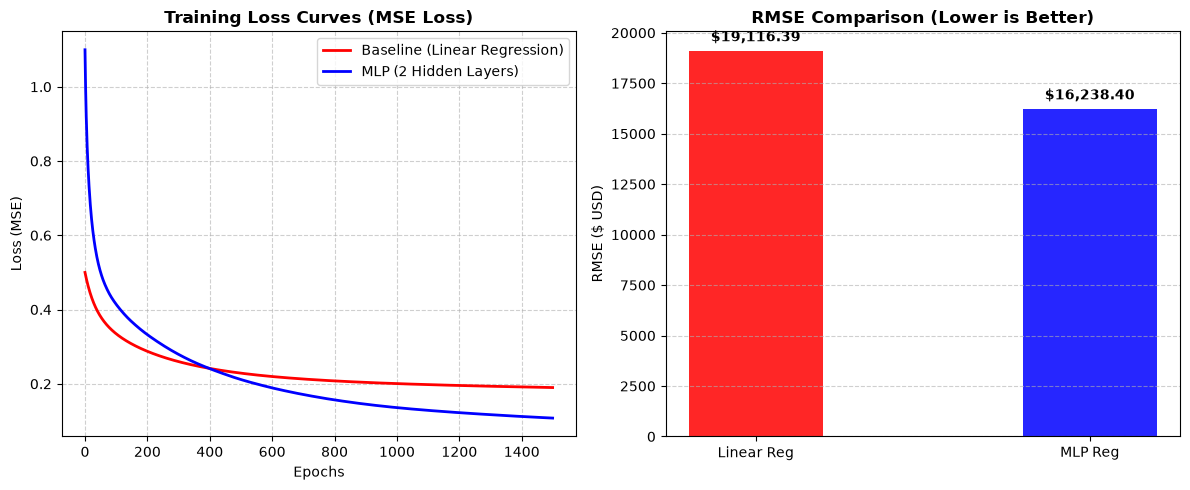

In [248]:
plt.figure(figsize=(12, 5))

#  Loss 
plt.subplot(1, 2, 1)
plt.plot(base_model.loss_hist, label='Baseline (Linear Regression)', color='red', linewidth=2)
plt.plot(mlp_model.loss_hist, label='MLP (2 Hidden Layers)', color='blue', linewidth=2)
plt.title('Training Loss Curves (MSE Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# bar chart
plt.subplot(1, 2, 2)
models = ['Linear Reg', 'MLP Reg']
rmse_vals = [rmse_val, mlp_rmse_val]
bars = plt.bar(models, rmse_vals, color=['red', 'blue'], alpha=0.85, width=0.4)
plt.title('RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
plt.ylabel('RMSE ($ USD)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 300, f"${yval:,.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Comparions 

the result depicts that Mlp is better than linear reggression  

mlp beats linear regression here because linear regression just draws a straight flat line through everything. it misses how age education and location work together to change income. mlp uses hidden layers so it can actually see those patterns.

for accuracy linear regression gets an r2 score of 0.522 so it only gets about 52% of the data right. mlp gets 0.655 r2 which is more than 65% of the pattern.

linear regression stops getting better very early at around 400 epochs because it cannot flex more. mlp keeps getting better slowly all the way to 1500 epochs because its hidden layers keep tweaking things.

the only bad part is time. linear regression finishes in 0.056 seconds but mlp needs 1.57 seconds. that is 28 times slower because mlp has to do extra math going forward and backward through its 32 and 16 node layers.

Softmax Regression

In [249]:
df = pd.read_csv('bike_buyers.csv')
df_clean = df.drop(columns=['ID']).copy()
#print(df_clean)
num_cols = ['Income', 'Children', 'Cars', 'Age']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
cat_cols = ['Marital Status', 'Gender', 'Education', 'Home Owner', 'Commute Distance', 'Region', 'Purchased Bike']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
X = df_clean.drop(columns=['Occupation'])
y_raw = df_clean['Occupation'].values
#print(y_raw)

le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
ohe = OneHotEncoder(sparse_output=False)
y_ohe = ohe.fit_transform(y_encoded.reshape(-1, 1))
ct = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

X_proc = ct.fit_transform(X)

X_train, X_test, y_train_ohe, y_test_ohe, y_train_raw, y_test_raw = train_test_split(
    X_proc, y_ohe, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [250]:
class SoftmaxRegression:
    def __init__(self, lr=0.1, ep=1500):
        self.lr = lr
        self.ep = ep
        self.w = None
        self.b = None
        self.loss_history = []

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        #print(exp_z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, Y):
        t0 = time.time()
        n, f = X.shape
        c = Y.shape[1]
        
        self.w = np.zeros((f, c))
        self.b = np.zeros((1, c))

        for _ in range(self.ep):
            probs = self.softmax(np.dot(X, self.w) + self.b)
            loss = -np.mean(np.sum(Y * np.log(probs + 1e-15), axis=1))
            self.loss_history.append(loss)
            err = probs - Y
            dw = (1 / n) * np.dot(X.T, err)
            db = (1 / n) * np.sum(err, axis=0, keepdims=True)
            self.w -= self.lr * dw
            self.b -= self.lr * db
        self.t_train = time.time() - t0

    def predict(self, X):
        probs = self.softmax(np.dot(X, self.w) + self.b)
        return np.argmax(probs, axis=1)

base_model = SoftmaxRegression(lr=0.1, ep=1500)
base_model.fit(X_train, y_train_ohe)
base_preds = base_model.predict(X_test)

In [ ]:
class MLP:
    def __init__(self, archit, lr=0.05, ep=1500):
        self.archit = archit
        self.lr = lr
        self.ep = ep
        self.loss_history = []
        self.initialize_parameters()

    def initialize_parameters(self):
        np.random.seed(42)
        self.weights = []
        self.biases = []
        for i in range(len(self.archit) - 1):
            w = np.random.randn(self.archit[i], self.archit[i+1]) * np.sqrt(2.0 / self.archit[i])
            b = np.zeros((1, self.archit[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def relu(self, z): 
        return np.maximum(0, z)
    
    def d_relu(self, z): 
        return (z > 0).astype(float)
    
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward_prop(self, X):
        acts, zs = [X], []
        curr = X
        for i in range(len(self.weights) - 1):
            z = np.dot(curr, self.weights[i]) + self.biases[i]
            zs.append(z)
            curr = self.relu(z)
            acts.append(curr)
        z_out = np.dot(curr, self.weights[-1]) + self.biases[-1]
        zs.append(z_out)
        acts.append(self.softmax(z_out))
        return acts, zs

    def backward_prop(self, X, Y, acts, zs):
        m = X.shape[0]
        dW, db = [None] * len(self.weights), [None] * len(self.biases)
        dZ = acts[-1] - Y
        dW[-1] = (1 / m) * np.dot(acts[-2].T, dZ)
        db[-1] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)
        for l in range(len(self.weights) - 2, -1, -1):
            dA = np.dot(dZ, self.weights[l+1].T)
            dZ = dA * self.d_relu(zs[l])
            dW[l] = (1 / m) * np.dot(acts[l].T, dZ)
            db[l] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)
        return dW, db

    def fit(self, X, Y):
        t0 = time.time()
        for _ in range(self.ep):
            acts, zs = self.forward_prop(X)
            probs = acts[-1]
            loss = -np.mean(np.sum(Y * np.log(probs + 1e-15), axis=1))
            self.loss_history.append(loss)
            
            dW, db = self.backward_prop(X, Y, acts, zs)
            for i in range(len(self.weights)):
                self.weights[i] -= self.lr * dW[i]
                self.biases[i] -= self.lr * db[i]
                
        self.t_train = time.time() - t0

    def predict(self, X):
        acts, _ = self.forward_prop(X)
        return np.argmax(acts[-1], axis=1)

mlp_model = MLP(archit=[X_train.shape[1], 32, 16, 5], lr=0.05, ep=1500)
mlp_model.fit(X_train, y_train_ohe)
mlp_preds = mlp_model.predict(X_test)

In [252]:
def compute_classification_metrics(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    accuracy = np.mean(y_true == y_pred)
    #print(accuracy)
    return {
        "Accuracy": round(float(accuracy), 4)
    }

def get_assignment_results():
    base_preds = base_model.predict(X_test)
    mlp_preds = mlp_model.predict(X_test)
    t_base_time = getattr(base_model, 't_train', getattr(base_model, 'train_time', getattr(base_model, 't_base', 0.0)))
    t_mlp_time = getattr(mlp_model, 't_train', getattr(mlp_model, 'train_time', 0.0))
    mlp_arch = getattr(mlp_model, 'architecture', getattr(mlp_model, 'archit', None))
    
    return {
        "dataset_name": "bike_buyers.csv",
        "n_samples": X.shape[0],
        "n_features": X_train.shape[1] if 'X_train' in globals() else X_proc.shape[1],
        "problem_type": "Multi-Class Classification",
        "primary_metric": "Accuracy",
        "baseline_model": {
            "metrics": compute_classification_metrics(y_test_raw, base_preds),
            "training_time": round(float(t_base_time), 4)
        },
        "mlp_model": {
            "archit": mlp_arch,
            "metrics": compute_classification_metrics(y_test_raw, mlp_preds),
            "training_time": round(float(t_mlp_time), 4)
        }
    }
results = get_assignment_results()

print("\nDataset:", results["dataset_name"])
print("Samples:", results["n_samples"])
print("Features:", results["n_features"])
print("Problem Type:", results["problem_type"])
print("Primary Metric:", results["primary_metric"])
print("\nBaseline Model:")
print(results["baseline_model"])
print("\nMLP Model:")
print(results["mlp_model"])


Dataset: bike_buyers.csv
Samples: 1000
Features: 18
Problem Type: Multi-Class Classification
Primary Metric: Accuracy

Baseline Model:
{'metrics': {'Accuracy': 0.71}, 'training_time': 0.4447}

MLP Model:
{'archit': [18, 32, 16, 5], 'metrics': {'Accuracy': 0.825}, 'training_time': 1.3276}


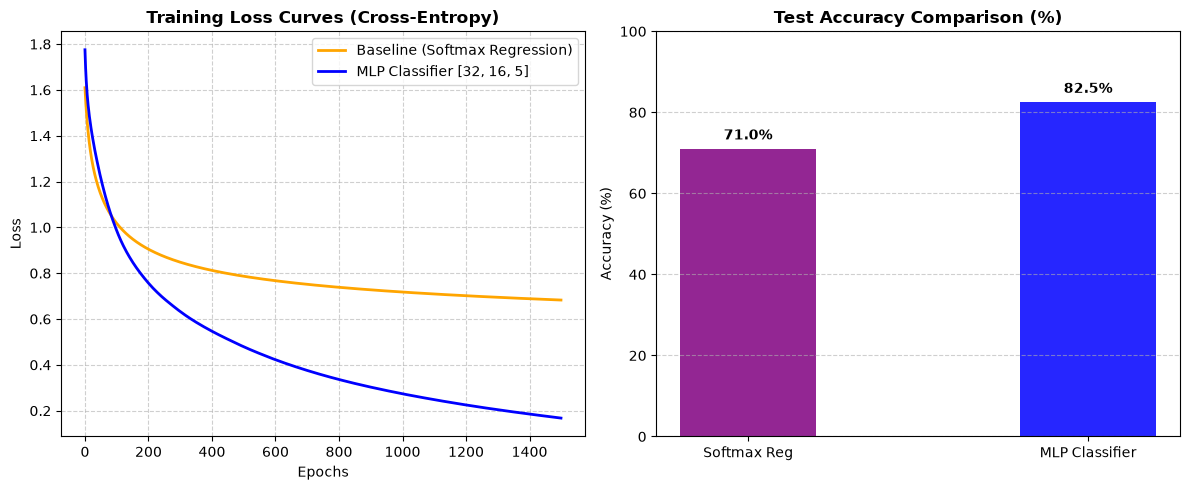

In [253]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss 
plt.subplot(1, 2, 1)
plt.plot(base_model.loss_history, label='Baseline (Softmax Regression)', color='orange', linewidth=2)
plt.plot(mlp_model.loss_history, label='MLP Classifier [32, 16, 5]', color='blue', linewidth=2)
plt.title('Training Loss Curves (Cross-Entropy)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# bar chart
plt.subplot(1, 2, 2)
models = ['Softmax Reg', 'MLP Classifier']
accs = [np.mean(base_preds == y_test_raw) * 100, np.mean(mlp_preds == y_test_raw) * 100]
bars = plt.bar(models, accs, color=['purple', 'blue'], alpha=0.85, width=0.4)
plt.title('Test Accuracy Comparison (%)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Comparison

Mlp works much better than simple softmax regression here. softmax just draws straight lines to separate groups so it gets stuck at 71% test accuracy. mlp uses hidden layers with 32 and 16 nodes to see complex patterns between age income and education getting up to 82.5% accuracy.

looking at the loss loss for softmax stops dropping very early at around 0.68 because its math is too limited. mlp keeps bringing loss down steadily to about 0.17 over all 1500 epochs because its hidden layers learn much better.

the only drawback is compute time. softmax finishes in 0.449 seconds while mlp takes 1.276 seconds which is about 2.8 times slower due to extra matrix math going forward and backward. but getting 11.5% better accuracy makes that extra second worth it.